# Module 03: EDA

In [3]:
%pip install -q ISLP

# packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split
from ISLP import load_data

# set seed
seed = 2323

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.6 MB/s eta 0:00:00


### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [4]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [5]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [6]:
for col in Hitters.columns:
    print(col, Hitters[col].dtype)

AtBat int64
Hits int64
HmRun int64
Runs int64
RBI int64
Walks int64
Years int64
CAtBat int64
CHits int64
CHmRun int64
CRuns int64
CRBI int64
CWalks int64
League category
Division category
PutOuts int64
Assists int64
Errors int64
Salary float64
NewLeague category


### Before doing any other analyses, let's create training and test sets.

In [7]:
Train, Test = train_test_split(Hitters,
                               random_state=seed,
                               test_size=0.40,
                               shuffle=True)

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The columns starting with C show career totals. The matching columns without C only show stats from the 1986 season.

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

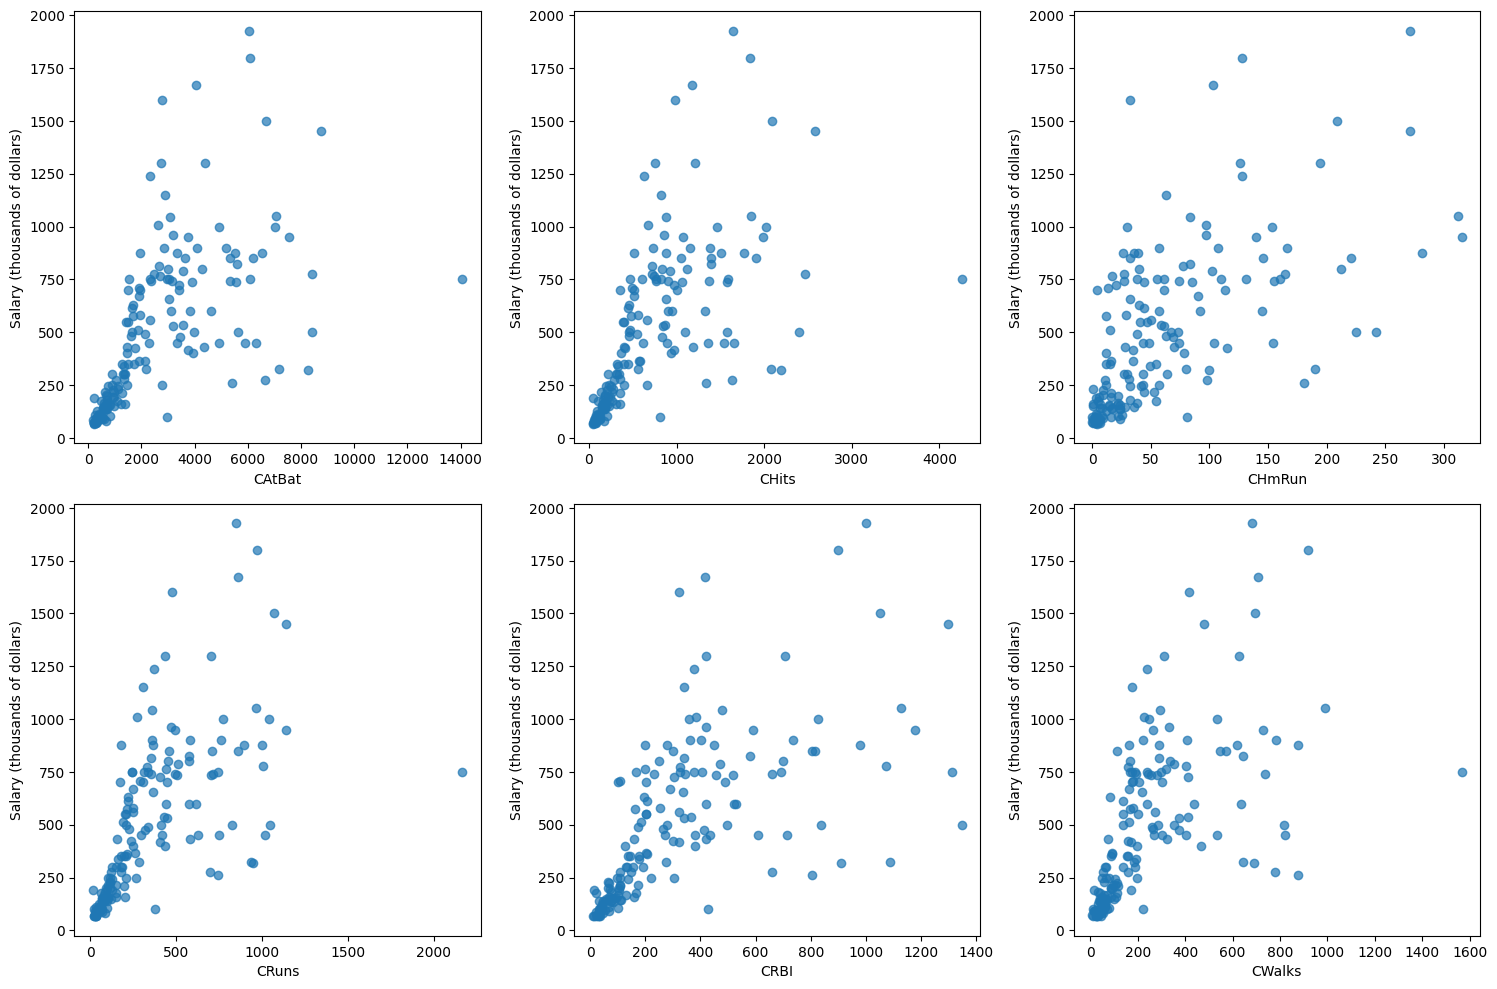

In [8]:
subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]
fig, axes = subplots(nrows=2, ncols=3, figsize=(15, 10))

for ax, col in zip(axes.flat, subset.columns):
    ax.scatter(subset[col], Train['Salary'], alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel('Salary (thousands of dollars)')

plt.tight_layout()
plt.show()

### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [9]:
Train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,164.000000
mean,381.829016,101.549223,10.150259,50.751295,47.093264,38.445596,7.253886,2587.440415,702.222798,59.668394,345.378238,308.373057,248.388601,276.865285,105.300518,8.051813,493.032951
std,145.679181,44.267521,8.228711,24.784284,24.912589,21.136915,4.858712,2285.947344,649.010165,66.449102,322.848870,297.885894,250.777436,262.957701,137.135778,6.783667,386.159522
min,19.000000,7.000000,0.000000,1.000000,2.000000,1.000000,1.000000,41.000000,13.000000,0.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,67.500000
25%,271.000000,68.000000,4.000000,32.000000,29.000000,22.000000,3.000000,730.000000,185.000000,14.000000,98.000000,82.000000,63.000000,109.000000,7.000000,3.000000,160.000000
50%,369.000000,95.000000,8.000000,47.000000,43.000000,34.000000,6.000000,1876.000000,476.000000,36.000000,238.000000,202.000000,166.000000,211.000000,38.000000,6.000000,420.833500
75%,508.000000,136.000000,14.000000,68.000000,61.000000,53.000000,11.000000,3754.000000,1000.000000,78.000000,494.000000,419.000000,332.000000,317.000000,173.000000,12.000000,750.000000
max,687.000000,223.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,315.000000,2165.000000,1348.000000,1566.000000,1320.000000,492.000000,32.000000,1925.571000


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

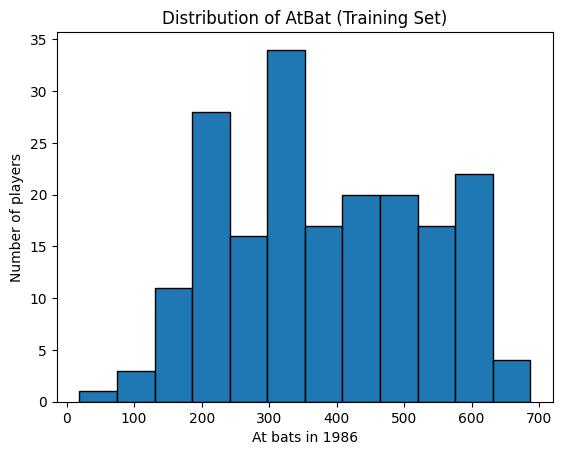

In [10]:
plt.hist(Train['AtBat'], bins=12, edgecolor='black')
plt.xlabel('At bats in 1986')
plt.ylabel('Number of players')
plt.title('Distribution of AtBat (Training Set)')
plt.show()

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [11]:
Train = Train.copy()
Train['AtBat_st'] = (Train['AtBat'] - Train['AtBat'].mean()) / Train['AtBat'].std()
Train[['AtBat', 'AtBat_st']].head()

,AtBat,AtBat_st
3,496,0.783715
63,216,-1.138317
27,474,0.632698
130,306,-0.520521
93,511,0.886681


### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [12]:
len(Train.loc[Train['AtBat_st'].between(-1, 1)])

115

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

Salary has a count of 164, but the training set has 193 rows. That means 29 salary values are missing.

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

If missing values were entered as 0 or -999, describe() would count them as real numbers. The count would look complete even though some data is missing.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

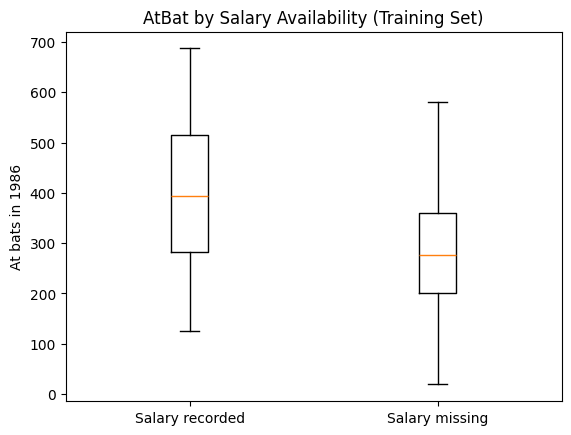

In [13]:
salary_present = Train.loc[Train['Salary'].notna(), 'AtBat']
salary_missing = Train.loc[Train['Salary'].isna(), 'AtBat']
plt.boxplot([salary_present, salary_missing])
plt.xticks([1, 2], ['Salary recorded', 'Salary missing'])
plt.ylabel('At bats in 1986')
plt.title('AtBat by Salary Availability (Training Set)')
plt.show()

### Create a correlation matrix for all numeric features in the training set

In [14]:
correlations = Train.corr(numeric_only=True)
display(correlations)
print('Correlations with Salary:')
print(correlations['Salary'].drop('Salary').sort_values(ascending=False))

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,AtBat_st
AtBat,1.000000,0.963324,0.540323,0.906579,0.798717,0.631824,-0.039232,0.126602,0.146763,0.150166,0.164892,0.145779,0.056578,0.345879,0.363085,0.368162,0.401390,1.000000
Hits,0.963324,1.000000,0.516853,0.914739,0.795316,0.605876,-0.028717,0.133316,0.163329,0.136865,0.175542,0.153011,0.065178,0.312858,0.310422,0.301725,0.432558,0.963324
HmRun,0.540323,0.516853,1.000000,0.618439,0.840613,0.385425,0.009072,0.078981,0.076914,0.411917,0.110767,0.218285,0.080296,0.222084,-0.069088,0.062840,0.326021,0.540323
Runs,0.906579,0.914739,0.618439,1.000000,0.786635,0.711346,-0.069584,0.083770,0.103859,0.160979,0.159683,0.115628,0.099025,0.289952,0.184714,0.217297,0.441499,0.906579
RBI,0.798717,0.795316,0.840613,0.786635,1.000000,0.553527,0.046705,0.165837,0.180526,0.375072,0.191452,0.285074,0.117109,0.323825,0.138896,0.217983,0.414623,0.798717
Walks,0.631824,0.605876,0.385425,0.711346,0.553527,1.000000,0.037943,0.137157,0.147019,0.194766,0.205250,0.167453,0.312812,0.317000,0.139008,0.160753,0.458462,0.631824
Years,-0.039232,-0.028717,0.009072,-0.069584,0.046705,0.037943,1.000000,0.925308,0.906857,0.730478,0.882559,0.882835,0.836809,0.071301,-0.091915,-0.160476,0.541390,-0.039232
CAtBat,0.126602,0.133316,0.078981,0.083770,0.165837,0.137157,0.925308,1.000000,0.995185,0.775167,0.979705,0.948617,0.894573,0.120875,-0.000507,-0.068187,0.616677,0.126602
CHits,0.146763,0.163329,0.076914,0.103859,0.180526,0.147019,0.906857,0.995185,1.000000,0.761920,0.983128,0.945002,0.883547,0.132818,-0.003372,-0.062669,0.629875,0.146763
CHmRun,0.150166,0.136865,0.411917,0.160979,0.375072,0.194766,0.730478,0.775167,0.761920,1.000000,0.782490,0.912134,0.750795,0.126756,-0.129640,-0.141514,0.616170,0.150166


Correlations with Salary:
CRuns       0.649791
CRBI        0.641038
CHits       0.629875
CAtBat      0.616677
CHmRun      0.616170
CWalks      0.598203
Years       0.541390
Walks       0.458462
Runs        0.441499
Hits        0.432558
RBI         0.414623
AtBat       0.401390
AtBat_st    0.401390
HmRun       0.326021
PutOuts     0.314053
Assists    -0.005242
Errors     -0.027683
Name: Salary, dtype: float64


### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

One way is to use the median salary of players with similar at-bat totals. Another is to predict missing salaries with a regression model using career runs or RBIs, since those have strong correlations with salary. Both methods would use only the training data.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals.
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set).
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set).

In [15]:
TotHits = Train['Hits'].sum()
TotWalks = Train['Walks'].sum()
TotAtBat = Train['AtBat'].sum()
Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat - TotHits - TotWalks]
print('Hits:', TotHits, 'Walks:', TotWalks, 'At bats:', TotAtBat)

Hits: 19599 Walks: 7420 At bats: 73693


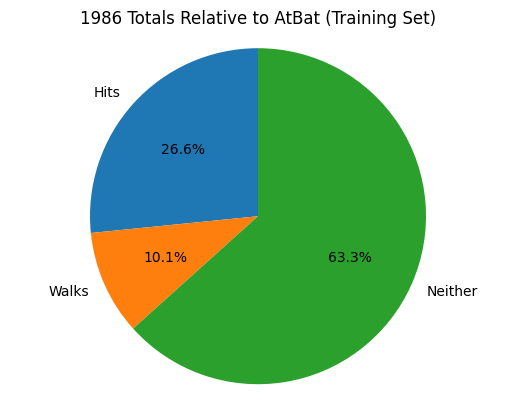

In [16]:
# Use the AtBat denominator requested in the exercise.
# In baseball, walks are not officially counted as at-bats.
plt.pie(Totals, labels=Labels, autopct='%1.1f%%', startangle=90)
plt.title('1986 Totals Relative to AtBat (Training Set)')
plt.axis('equal')
plt.show()

### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [17]:
# Keep AVG as a proportion to match the 0.25 and 0.31 cutoffs.
Train['AVG'] = Train['Hits'] / Train['AtBat']
Train[['Hits', 'AtBat', 'AVG']].head()

,Hits,AtBat,AVG
3,141,496,0.284274
63,53,216,0.245370
27,129,474,0.272152
130,104,306,0.339869
93,138,511,0.270059


### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low.

In [18]:
Train['AVG_bin'] = 'medium'
Train.loc[Train['AVG'] < 0.25, 'AVG_bin'] = 'low'
Train.loc[Train['AVG'] > 0.31, 'AVG_bin'] = 'high'

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [19]:
Train['AVG_bin'].value_counts()

,count
AVG_bin,
medium,114
low,65
high,14


Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly.

In [20]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

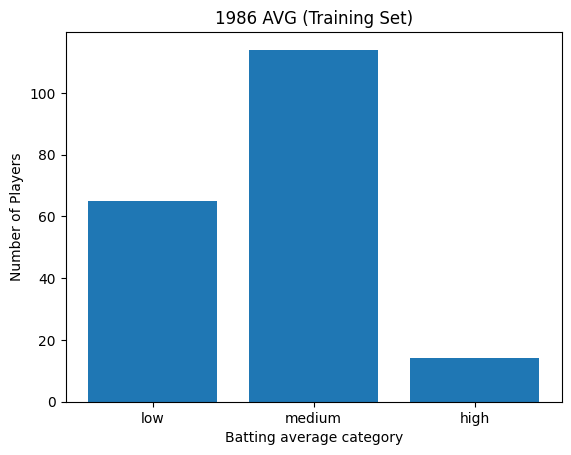

In [21]:
plt.bar(range(len(indexMap)), reordered_list)
plt.title('1986 AVG (Training Set)')
plt.ylabel('Number of Players')
plt.xlabel('Batting average category')
plt.xticks(range(len(indexMap)), indexMap)
plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

This follows the idea of the width method because we grouped players using fixed batting average cutoffs of 0.25 and 0.31. Players below 0.25 went into the low group, players from 0.25 through 0.31 went into the medium group, and players above 0.31 went into the high group. We didn't choose the cutoffs to give each group the same number of players, which is what the depth method would do. That's why the bars can have different heights. These are custom ranges, so the groups don't all cover an equal width.